# Horizontal Pair Registration - edge-focused PCC

Two side-by-side tiles (**A = left, B = right**) overlapping along the column (x) axis.
Registration is **phase cross-correlation on the overlap strips after a high-pass prefilter
and a Hann window** (the window tapers the strip borders to zero so hard edges / bright
horizontal streaks don't leak energy into the FFT and steal the peak).

The one twist here: instead of correlating over the *full-height* overlap box (which lets PCC
slide up and down over empty rows and pick up a spurious vertical shift), we first threshold the
tiles into a tissue **mask** (`OTSU_MULTIPLIER`), find where the tissue sits inside the overlap,
and shrink the box's top and bottom to **hug the tissue edge** (plus a little padding, `EDGE_PAD_PX`).
The box **width never changes**. If the tissue runs off the top or bottom of the tile the box just
hugs that edge.

Blending is **sinusoidal (raised-cosine) cross-fade** over the overlap. Everything is shown
**naive vs registered**: R/G/Y overlay before/after the shift, and the final stitched image both ways.

In [70]:
# -- Imports -------------------------------------------------------
import warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tifffile
from skimage.registration import phase_cross_correlation
from skimage.filters import threshold_otsu
from scipy.ndimage import gaussian_filter

matplotlib.rcParams['figure.dpi'] = 120

In [71]:
# -- Core helpers --------------------------------------------------

def load_tile(path):
    img = tifffile.imread(str(path)).astype('float32')
    while img.ndim > 2:
        img = img[0]
    return img


def norm_disp(img):
    lo, hi = img.min(), img.max()
    return (img - lo) / (hi - lo + 1e-9)


def highpass(img, sigma=12.0):
    """Subtract a large-sigma Gaussian to strip the smooth brightness envelope
    (residual vignette + tissue low-frequency gradient) so the true-texture
    correlation peak dominates. High-pass, NOT band-pass."""
    img = img.astype('float32')
    return img - gaussian_filter(img, sigma)


def register_pcc(strip_a, strip_b, upsample=20, highpass_sigma=12.0):
    """Phase cross-correlation of two overlap strips (high-passed, windowed,
    unmasked). Returns (dy, dx): strip_b aligns to strip_a when shifted by (dy, dx).

    A separable Hann window is applied before the FFT. Phase correlation whitens
    the magnitude spectrum, so any single dominant structure dictates the peak.
    The hard strip borders (and bright near-horizontal features like the light-
    sheet reflection streak) leak a strong cross of energy through the FFT that can
    capture the peak on a spurious cross-axis shift -- e.g. a horizontal seam that
    should have dx~=-45, dy~=0 instead locks to dy=-25, dx=0. Tapering the strip to
    zero at its edges (standard practice for phase correlation, like the high-pass)
    removes that leakage so the real texture peak wins."""
    a, b = strip_a, strip_b
    if a.shape != b.shape:
        r = min(a.shape[0], b.shape[0]); c = min(a.shape[1], b.shape[1])
        a, b = a[:r, :c], b[:r, :c]
    if highpass_sigma:
        a, b = highpass(a, highpass_sigma), highpass(b, highpass_sigma)
    win = np.hanning(a.shape[0])[:, None] * np.hanning(a.shape[1])[None, :]
    a, b = a * win, b * win
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        shift, _, _ = phase_cross_correlation(a, b, upsample_factor=upsample)
    return float(shift[0]), float(shift[1])


def edge_focus_box(strip_a, strip_b, thresh, pad_px, min_row_frac=0.02, min_lines=32):
    """Rows of the overlap box to keep, cropped to the tissue edge.

    Threshold both overlap strips into a foreground mask (pixels > `thresh`); a
    row counts as tissue when more than `min_row_frac` of it is foreground in
    EITHER strip. Return (r0, r1) spanning the tissue rows padded by `pad_px`,
    clamped to the strip height -- so tissue running off the top/bottom makes the
    box hug that edge. Falls back to the full height when there is too little
    tissue to trust (fewer than `min_lines` rows)."""
    h = min(strip_a.shape[0], strip_b.shape[0])
    a, b = strip_a[:h], strip_b[:h]
    mask = (a > thresh) | (b > thresh)
    cover = mask.mean(axis=1)                       # foreground fraction per row
    rows = np.where(cover > min_row_frac)[0]
    if rows.size == 0:
        return 0, h                                 # no tissue: keep full box
    r0 = max(0, int(rows[0]) - pad_px)
    r1 = min(h, int(rows[-1]) + 1 + pad_px)
    if r1 - r0 < min_lines:
        return 0, h
    return r0, r1


def enough_signal(strip_a, strip_b, thresh, min_signal_frac):
    """Whether the two overlap strips carry enough tissue to trust PCC.

    Builds the same foreground mask edge_focus_box uses (pixels > thresh) and
    measures the fraction of EACH strip that is signal. Returns
    (ok, frac_a, frac_b): ok is False when EITHER strip has less than
    min_signal_frac of its pixels above threshold -- too little actual signal in
    the overlap to register reliably, so the caller skips PCC and falls back to
    the nominal assumed overlap (dy=dx=0)."""
    frac_a = float((strip_a > thresh).mean())
    frac_b = float((strip_b > thresh).mean())
    return (frac_a >= min_signal_frac and frac_b >= min_signal_frac), frac_a, frac_b


def sinusoid_ramp(n, feather):
    """Length-n weight: 1 in the interior, a raised-cosine ease from ~0 to 1 over
    `feather` px at each end -> a smooth sinusoidal cross-fade across overlaps."""
    w = np.ones(n, dtype='float32')
    f = int(min(feather, n // 2))
    if f > 0:
        t = (np.arange(f) + 1) / (f + 1)            # (0,1)
        edge = (0.5 * (1 - np.cos(np.pi * t))).astype('float32')   # sinusoidal
        w[:f] = edge
        w[-f:] = edge[::-1]
    return w


def stitch_h(a, b, overlap, dy, dx, register=True):
    """Place B to the right of A (B left edge at x = w_a - overlap + dx, top at
    y = dy) and blend the overlap with a sinusoidal cross-fade. register=False
    forces dy=dx=0 (the naive assumed-overlap baseline). Returns the canvas."""
    sdy = int(round(dy)) if register else 0
    sdx = int(round(dx)) if register else 0
    b_y0, b_x0 = sdy, a.shape[1] - overlap + sdx
    y_min = min(0, b_y0); x_min = min(0, b_x0)
    H = max(a.shape[0], b_y0 + b.shape[0]) - y_min
    W = max(a.shape[1], b_x0 + b.shape[1]) - x_min
    acc = np.zeros((H, W), 'float32'); wsum = np.zeros((H, W), 'float32')
    feather = max(1, overlap)
    for img, y0, x0 in [(a, 0, 0), (b, b_y0, b_x0)]:
        yy, xx = y0 - y_min, x0 - x_min
        w = np.broadcast_to(sinusoid_ramp(img.shape[1], feather)[None, :], img.shape).copy()
        w[img == 0] = 0.0                           # background never bleeds into a seam
        acc[yy:yy+img.shape[0], xx:xx+img.shape[1]] += w * img
        wsum[yy:yy+img.shape[0], xx:xx+img.shape[1]] += w
    return acc / np.maximum(wsum, 1e-6)

In [72]:
# -- Red/Green/Yellow overlay --------------------------------------
# Tile A -> red, Tile B -> green, so their overlap reads yellow.

def overlay_canvas(img_a, img_b, b_y0, b_x0):
    h_a, w_a = img_a.shape; h_b, w_b = img_b.shape
    oy, ox = max(0, -b_y0), max(0, -b_x0)           # shift so nothing is clipped
    H = max(h_a, b_y0 + h_b) + oy
    W = max(w_a, b_x0 + w_b) + ox
    ch_a = np.zeros((H, W), 'float32'); ch_b = np.zeros((H, W), 'float32')
    ch_a[oy:oy+h_a, ox:ox+w_a] = norm_disp(img_a)
    ch_b[b_y0+oy:b_y0+oy+h_b, b_x0+ox:b_x0+ox+w_b] = norm_disp(img_b)
    return np.stack([ch_a, ch_b, np.zeros_like(ch_a)], -1)


def compare_overlay(img_a, img_b, overlap, dy, dx):
    """Naive (dy=dx=0) vs registered (measured dy,dx) overlays, side by side."""
    w_a = img_a.shape[1]
    naive = overlay_canvas(img_a, img_b, 0, w_a - overlap)
    reg   = overlay_canvas(img_a, img_b, int(round(dy)), w_a - overlap + int(round(dx)))
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].imshow(naive, aspect='auto'); axes[0].set_title('BEFORE  (naive, dy=0, dx=0)', fontsize=9); axes[0].axis('off')
    axes[1].imshow(reg,   aspect='auto'); axes[1].set_title(f'AFTER  (registered, dy={dy:+.1f}, dx={dx:+.1f})', fontsize=9); axes[1].axis('off')
    fig.legend(handles=[mpatches.Patch(color=(1,0,0), label='Tile A only'),
                        mpatches.Patch(color=(0,1,0), label='Tile B only'),
                        mpatches.Patch(color=(1,1,0), label='Overlap (both)')],
               loc='upper right', fontsize=8, framealpha=0.6)
    fig.suptitle('Overlap agreement: before vs after the shift', fontsize=10)
    plt.tight_layout(); plt.show()

In [73]:
# -- User inputs ---------------------------------------------------
# Two horizontally adjacent tiles: A = left, B = right (same row, next column).

# Test Case 1: First 2 Tiles
TILE_PATHS = [
    "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[00 x 00]_C00_z0082.ome.tif",
    "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[00 x 01]_C00_z0082.ome.tif",
]

# Test Case 2:
# TILE_PATHS = [
#     "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[00 x 01]_C00_z0082.ome.tif",
#     "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[00 x 02]_C00_z0082.ome.tif",
# ]

# Test Case 3: 
# TILE_PATHS = [
#     "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[02 x 01]_C00_z0082.ome.tif",
#     "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[02 x 02]_C00_z0082.ome.tif",
# ]

# Test Case 4:
# TILE_PATHS = [
#     "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[02 x 00]_C00_z0082.ome.tif",
#     "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[02 x 01]_C00_z0082.ome.tif",
# ]

# Test Case 5:
TILE_PATHS = [
    "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[00 x 00]_C00_z0048.ome.tif",
    "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[00 x 01]_C00_z0048.ome.tif",
]

OVERLAP_FRAC    = 0.20     # assumed overlap, fraction of tile WIDTH
OTSU_MULTIPLIER = 0.5      # tissue mask threshold = OTSU_MULTIPLIER x Otsu(tile)
EDGE_PAD_PX     = 80       # rows to keep on either side of the tissue edge
UPSAMPLE        = 20       # PCC sub-pixel upsample factor
HIGHPASS_SIGMA  = 12       # Gaussian sigma for the high-pass prefilter
MIN_SIGNAL_FRAC = 0.05     # min fraction of EACH overlap strip that must be signal
                           # (foreground > tissue thresh) to register with PCC; below
                           # this, skip PCC and default to the nominal overlap (dy=dx=0)

Tile A (left) : (2560, 2160)
Tile B (right): (2560, 2160)
Tissue mask    : threshold = 1676.3  (Otsu x 0.5)


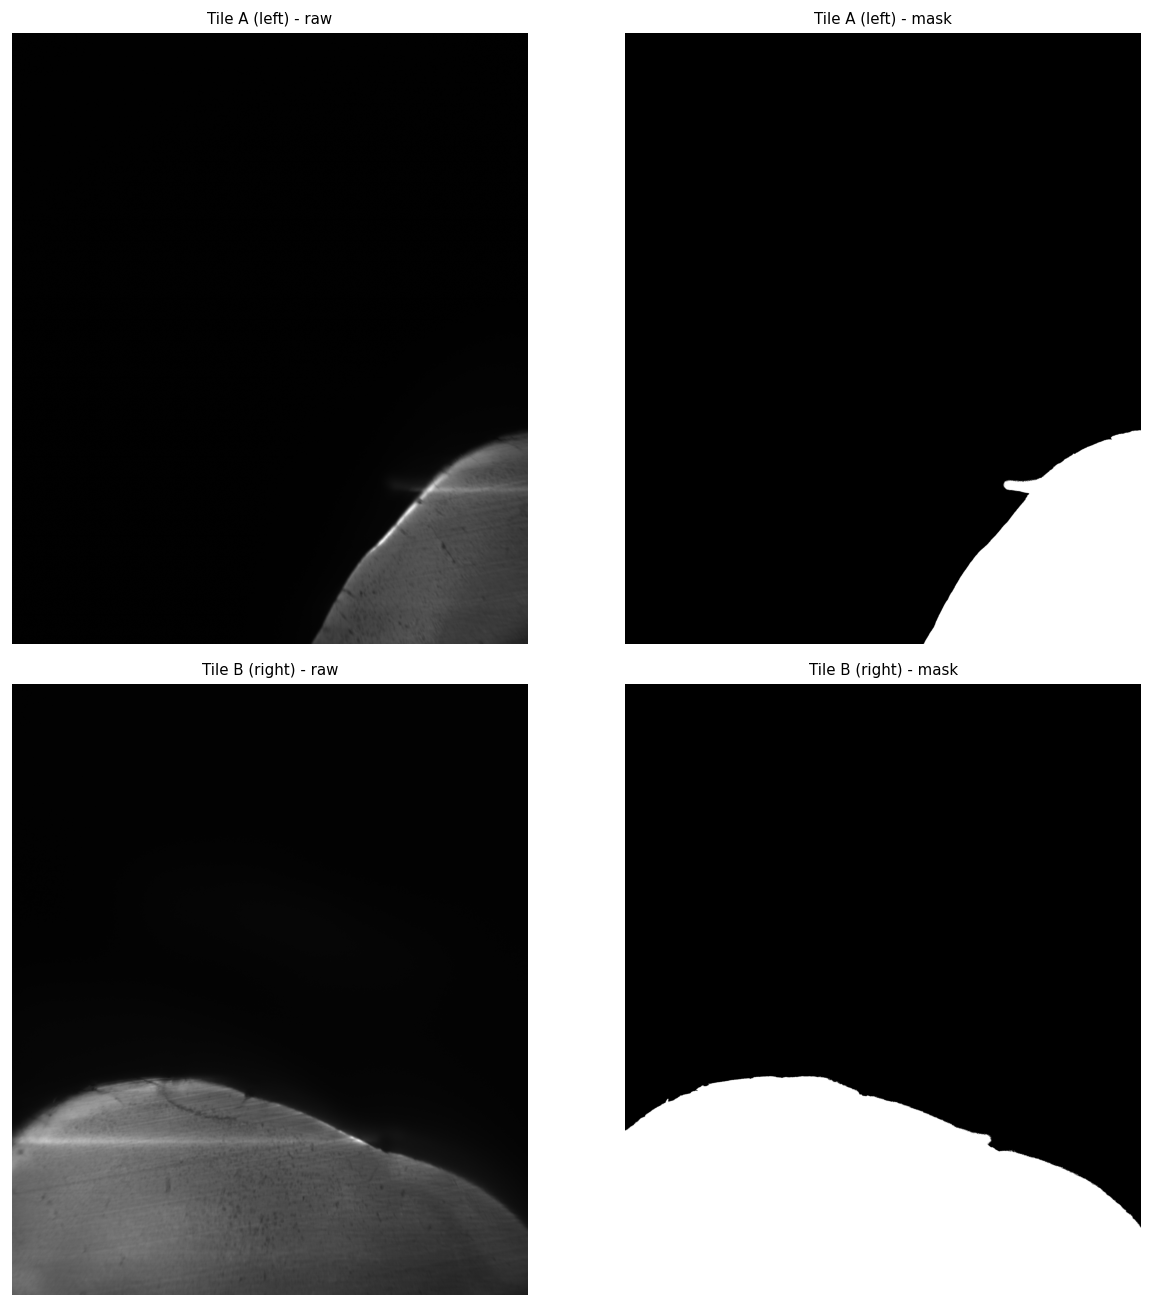

In [74]:
# -- Load and display the raw tiles + tissue masks -----------------
a, b = [load_tile(p) for p in TILE_PATHS]
print(f'Tile A (left) : {a.shape}')
print(f'Tile B (right): {b.shape}')

# Tissue mask threshold from an Otsu split over both tiles, scaled by the knob.
sample = np.concatenate([a[::8, ::8].ravel(), b[::8, ::8].ravel()])
thresh = OTSU_MULTIPLIER * threshold_otsu(sample)
print(f'Tissue mask    : threshold = {thresh:.1f}  (Otsu x {OTSU_MULTIPLIER})')

# Each raw tile next to its mask (pixels > threshold).
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for row, (img, name) in enumerate([(a, 'A (left)'), (b, 'B (right)')]):
    axes[row][0].imshow(norm_disp(img), cmap='gray')
    axes[row][0].set_title(f'Tile {name} - raw', fontsize=9); axes[row][0].axis('off')
    axes[row][1].imshow(img > thresh, cmap='gray')
    axes[row][1].set_title(f'Tile {name} - mask', fontsize=9); axes[row][1].axis('off')
plt.tight_layout(); plt.show()

### Edge-focused overlap box + PCC shift

Overlap        : 432px wide (full height 2560px)
Edge-focus box : rows 1584-2560  (976px tall, was 2560px)   [hugs bottom]
PCC shift      : dy=-0.85  dx=-50.95


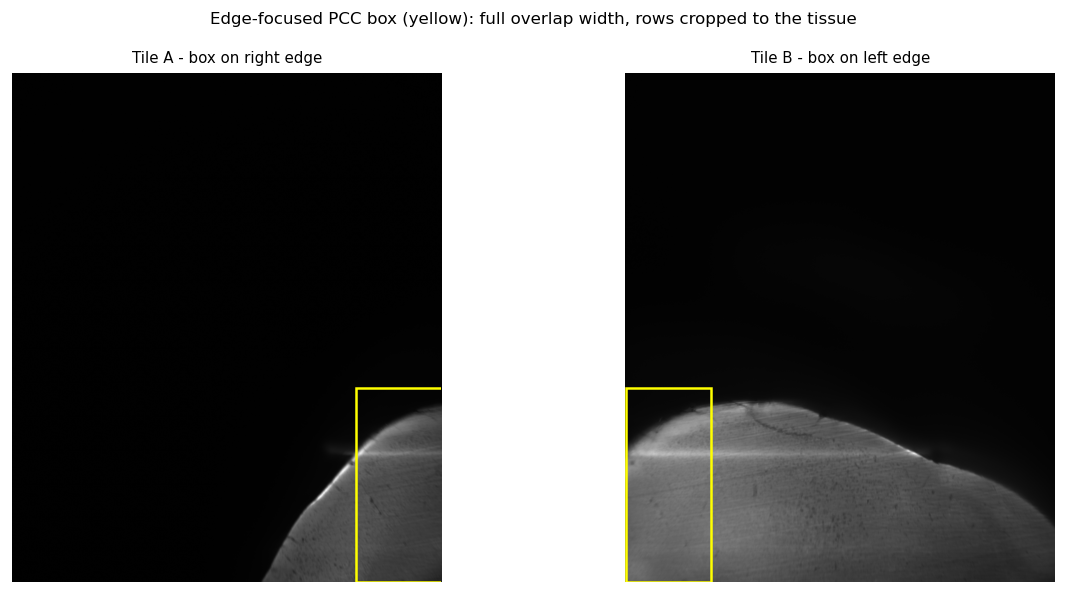

In [75]:
# -- Build the edge-focused box and register -----------------------
# Overlap strips span the full tile height; we crop their ROWS to the tissue edge
# (width unchanged), then run high-passed PCC on the cropped strips.
overlap = max(1, min(int(round(OVERLAP_FRAC * a.shape[1])), a.shape[1], b.shape[1]))
sa, sb = a[:, -overlap:], b[:, :overlap]          # A right edge, B left edge

r0, r1 = edge_focus_box(sa, sb, thresh, EDGE_PAD_PX)   # thresh from the load cell
print(f'Overlap        : {overlap}px wide (full height {a.shape[0]}px)')
print(f'Edge-focus box : rows {r0}-{r1}  ({r1-r0}px tall, was {a.shape[0]}px)'
      + ('   [hugs top]' if r0 == 0 else '')
      + ('   [hugs bottom]' if r1 == sa.shape[0] else ''))

sig_ok, frac_a, frac_b = enough_signal(sa, sb, thresh, MIN_SIGNAL_FRAC)
if sig_ok:
    dy, dx = register_pcc(sa[r0:r1], sb[r0:r1], UPSAMPLE, HIGHPASS_SIGMA)
    print(f'PCC shift      : dy={dy:+.2f}  dx={dx:+.2f}')
else:
    dy, dx = 0.0, 0.0   # too little signal in the overlap -> nominal overlap, no PCC
    print(f'Signal         : A={frac_a:.1%}  B={frac_b:.1%}  < {MIN_SIGNAL_FRAC:.1%}'
          f'  -> too little signal, skipping PCC, using nominal overlap (dy=dx=0)')

# Show where the box sits on each tile (overlap columns x edge-focus rows).
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, img, x0, ttl in [(axes[0], a, a.shape[1]-overlap, 'Tile A - box on right edge'),
                         (axes[1], b, 0,                  'Tile B - box on left edge')]:
    ax.imshow(norm_disp(img), cmap='gray')
    ax.add_patch(mpatches.Rectangle((x0, r0), overlap, r1-r0,
                 fill=False, edgecolor='yellow', lw=1.5))
    ax.set_title(ttl, fontsize=9); ax.axis('off')
fig.suptitle('Edge-focused PCC box (yellow): full overlap width, rows cropped to the tissue',
             fontsize=10)
plt.tight_layout(); plt.show()

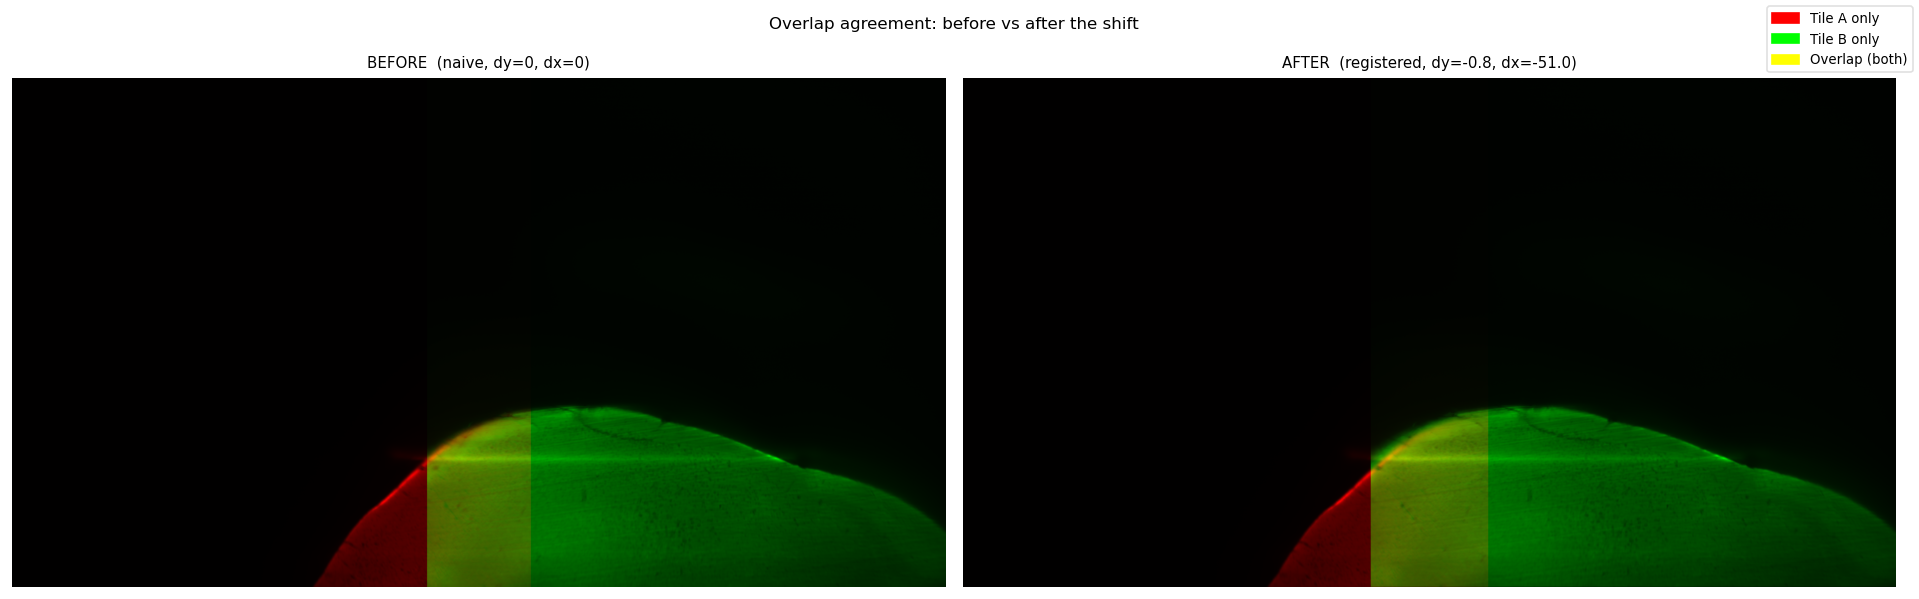

In [76]:
# -- R/G/Y overlay: before vs after the shift ----------------------
compare_overlay(a, b, overlap, dy, dx)

### Final stitched image - naive vs registered (sinusoidal blend)

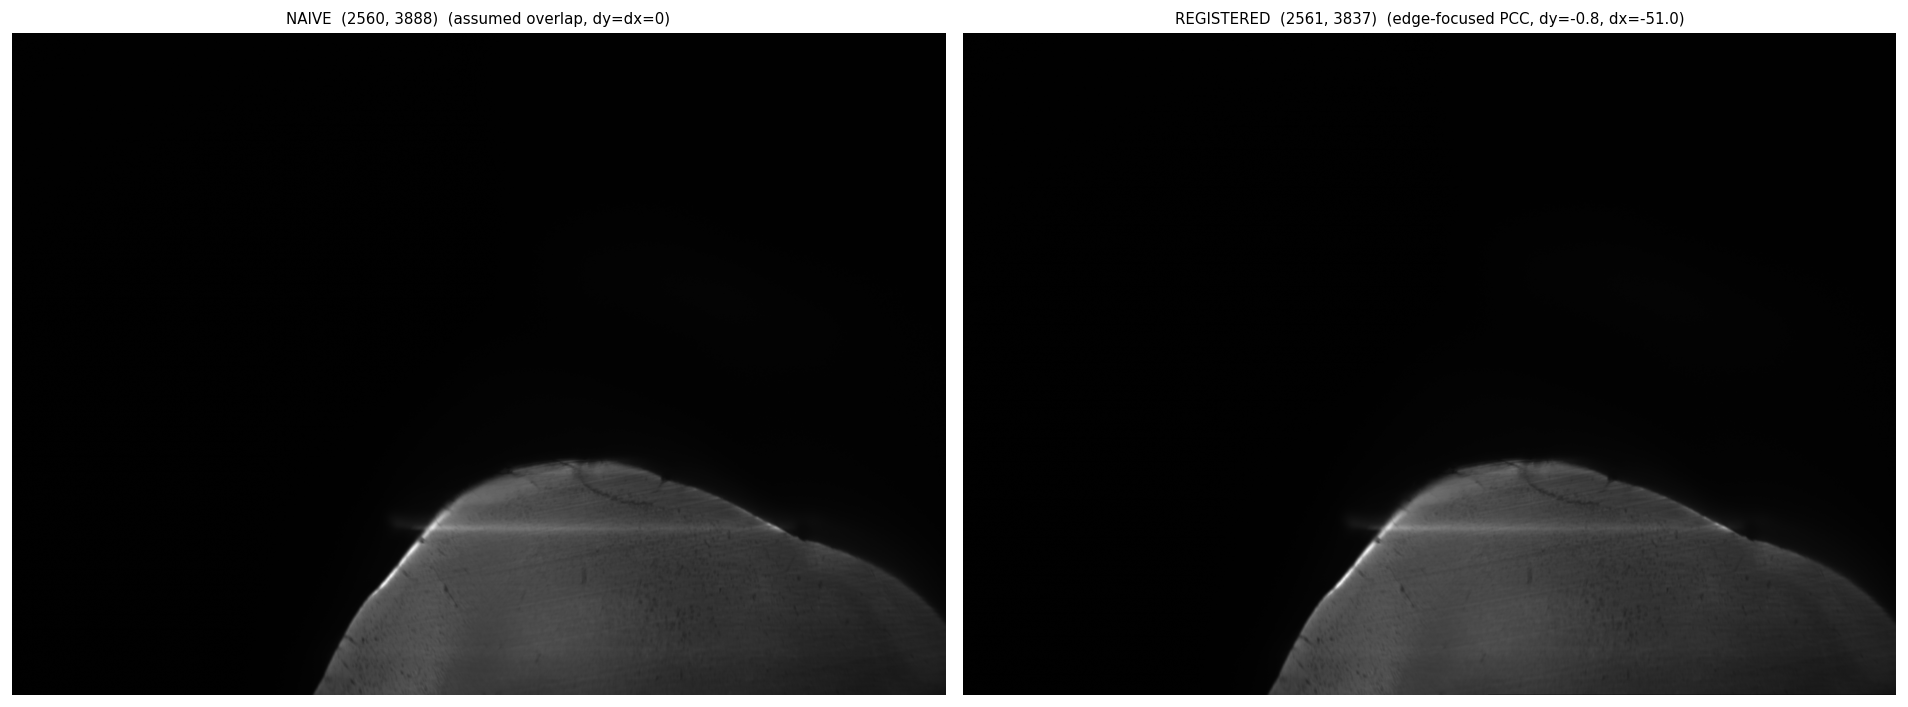

In [77]:
# -- Stitch both ways and show side by side ------------------------
# Both use a sinusoidal cross-fade over the overlap; naive assumes 20% overlap
# with no shift, registered applies the measured (dy, dx).
stitched_naive = stitch_h(a, b, overlap, dy, dx, register=False)
stitched_reg   = stitch_h(a, b, overlap, dy, dx, register=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(norm_disp(stitched_naive), cmap='gray', aspect='auto')
axes[0].set_title(f'NAIVE  {stitched_naive.shape}  (assumed overlap, dy=dx=0)', fontsize=9); axes[0].axis('off')
axes[1].imshow(norm_disp(stitched_reg), cmap='gray', aspect='auto')
axes[1].set_title(f'REGISTERED  {stitched_reg.shape}  (edge-focused PCC, dy={dy:+.1f}, dx={dx:+.1f})', fontsize=9); axes[1].axis('off')
plt.tight_layout(); plt.show()